# T005 · 化合物聚类

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授特定领域技能，并为研究项目提供管道模板作为起点。

作者：

- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2020, [Volkamer lab, Charité](https://volkamerlab.org/)

__教程 T005__：本教程是 [首篇 TeachOpenCADD 论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-019-0351-x) 中描述的 TeachOpenCADD 流程的一部分，包括 T001-T010 教程。

## 本教程目标

在本教程中，我们将了解聚类——一种流行的数据分组方法——在分子数据上的应用。

### Contents in _Theory_

* Introduction to clustering and Jarvis-Patrick algorithm
* Detailed explanation of Butina clustering
* Picking diverse compounds

### 实践内容

* 使用 Butina 算法进行聚类
* 可视化聚类结果
* 选择最终化合物列表
* 可视化簇内相似性

### 参考文献

* Butina 聚类（[_J. Chem. Inf. Comput. Sci._ (1999), **39**, 747-750](https://pubs.acs.org/doi/abs/10.1021/ci9803381)）
* Butina 聚类 RDKit（[repository](https://github.com/rdkit/UGM_2016/blob/master/Notebooks/Stiefl_RDKit_SwissBioisostere_clustering.ipynb)）

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 5
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## Theory

### 聚类的介绍和 Jarvis-Patrick 算法

[聚类](https://en.wikipedia.org/wiki/Cluster_analysis)可以通过将数据分组为子集（簇）来探索数据，聚类通常遵循不相似性的概念。距离函数是聚类算法的基础，评估对象（这里是化合物）的相似性或不相似性。在分子数据的背景下，常见的距离度量基于分子指纹（参见**教程 T004**）及其相似性度量。

### Butina 聚类的详细解释

Butina 聚类（[*J. Chem. Inf. Comput. Sci.* (1999), **39**, 747-750](https://pubs.acs.org/doi/abs/10.1021/ci9803381)）的开发背景是化学化合物数据库。它用于识别更小但同质的簇，前提是（至少）簇质心与簇中所有其他化合物的相似度高于给定阈值。

![Butina](images/butina_full.png)

*图 1：* Butina 聚类算法的理论示例，显示了最小簇大小的百分比（圆形）随不同阈值的变化。图像来自 [Butina 论文的配套信息](https://pubs.acs.org/doi/abs/10.1021/ci9803381)。

### 选择多样化的化合物

寻找具有代表性的化合物集合是化学信息学中的一个常见概念，例如用于选择用于实验验证的化合物。聚类是一种常见方法，用于从筛选库中选择一组多样化的化合物。在这篇教程中，我们将学习如何从每个簇中选择质心化合物作为代表。

## Practical

### 使用 Butina 算法进行聚类

应用以下示例，该示例来自 [RDKit 聚类文档](http://rdkit.org/docs/Cookbook.html#clustering-using-the-butina-algorithm)。

#### 加载数据并计算指纹

在这一部分，我们准备数据并为聚类生成指纹。我们导入必要的库，并加载在**教程 T002**中筛选过的 EGFR 数据集。此外，我们为所有化合物计算 Morgan 指纹（参见**教程 T004**）。

In [2]:
import time
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator

HERE = Path(_dh[-1])
DATA = HERE / "data"

random.seed(0)
np.random.seed(0)

In [3]:
# Load and have a look into data
# Filtered data taken from **Talktorial T002**
compound_df = pd.read_csv(
    DATA / "EGFR_compounds_lipinski.csv",
    index_col=0,
)
print("Dataframe shape:", compound_df.shape)
compound_df.head()

Dataframe shape: (4635, 10)


,molecule_chembl_id,IC50,units,smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,349.021459,3,1,5.2891,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.9333,True
2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,343.043258,5,1,3.5969,True
3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,339.011957,4,2,4.0122,True
4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,329.027607,5,2,3.5726,True


In [4]:
# Create molecules from SMILES and store in array
compounds = []
# .itertuples() returns a (index, column1, column2, ...) tuple per row
# we don't need index so we use _ instead
# note how we are slicing the dataframe to only the two columns we need now
for _, chembl_id, smiles in compound_df[["molecule_chembl_id", "smiles"]].itertuples():
    compounds.append((Chem.MolFromSmiles(smiles), chembl_id))
compounds[:5]

[(<rdkit.Chem.rdchem.Mol at 0x7f1c005418c0>, 'CHEMBL63786'),
 (<rdkit.Chem.rdchem.Mol at 0x7f1c00541930>, 'CHEMBL35820'),
 (<rdkit.Chem.rdchem.Mol at 0x7f1c005419a0>, 'CHEMBL53711'),
 (<rdkit.Chem.rdchem.Mol at 0x7f1c00541a10>, 'CHEMBL66031'),
 (<rdkit.Chem.rdchem.Mol at 0x7f1c00541af0>, 'CHEMBL53753')]

In [5]:
# Create fingerprints for all molecules
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=5)
fingerprints = [rdkit_gen.GetFingerprint(mol) for mol, idx in compounds]

# How many compounds/fingerprints do we have?
print("Number of compounds converted:", len(fingerprints))
print("Fingerprint length per compound:", len(fingerprints[0]))
# NBVAL_CHECK_OUTPUT

Number of compounds converted: 4635
Fingerprint length per compound: 2048


#### Tanimoto 相似性和距离矩阵

现在我们生成了指纹，我们可以计算化合物之间的成对距离。这里，我们使用 Tanimoto 相似性来度量，与**教程 T004**中介绍的相同。

In [6]:
def tanimoto_distance_matrix(fp_list):
    """Calculate distance matrix for fingerprint list"""
    dissimilarity_matrix = []
    # Notice how we are deliberately skipping the first and last items in the list
    # because we don't need to compare them against themselves
    for i in range(1, len(fp_list)):
        # Compare the current fingerprint against all the previous ones in the list
        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        # Since we need a distance matrix, calculate 1-x for every element in similarity matrix
        dissimilarity_matrix.extend([1 - x for x in similarities])
    return dissimilarity_matrix

See also [\[Rdkit-discuss\] BulkTanimotoSimilarity](https://sourceforge.net/p/rdkit/mailman/rdkit-discuss/thread/663770d4-b809-c599-e379-31f57380a1d0%40gmail.com/#msg36335970).

In [7]:
# Example: Calculate single similarity of two fingerprints
# NBVAL_CHECK_OUTPUT
sim = DataStructs.TanimotoSimilarity(fingerprints[0], fingerprints[1])
print(f"Tanimoto similarity: {sim:.2f}, distance: {1-sim:.2f}")

Tanimoto similarity: 0.73, distance: 0.27


In [8]:
# Example: Calculate distance matrix (distance = 1-similarity)
tanimoto_distance_matrix(fingerprints)[0:5]

[0.26996197718631176,
 0.26538461538461533,
 0.40866873065015474,
 0.09345794392523366,
 0.31182795698924726]

In [9]:
# Side note: That looked like a list and not a matrix.
# But it is a triangular similarity matrix in the form of a list
n = len(fingerprints)

# Calculate number of elements in triangular matrix via n*(n-1)/2
elem_triangular_matr = (n * (n - 1)) / 2
print(
    f"Elements in the triangular matrix ({elem_triangular_matr:.0f}) ==",
    f"tanimoto_distance_matrix(fingerprints) ({len(tanimoto_distance_matrix(fingerprints))})",
)
# NBVAL_CHECK_OUTPUT

Elements in the triangular matrix (10739295) == tanimoto_distance_matrix(fingerprints) (10739295)


#### 聚类分子：质心和排除球

在这一部分，我们对分子进行聚类并查看结果。

Define a clustering function.

In [10]:
def cluster_fingerprints(fingerprints, cutoff=0.2):
    """Cluster fingerprints
    Parameters:
        fingerprints
        cutoff: threshold for the clustering
    """
    # Calculate Tanimoto distance matrix
    distance_matrix = tanimoto_distance_matrix(fingerprints)
    # Now cluster the data with the implemented Butina algorithm:
    clusters = Butina.ClusterData(distance_matrix, len(fingerprints), cutoff, isDistData=True)
    clusters = sorted(clusters, key=len, reverse=True)
    return clusters

根据指纹相似性对分子进行聚类。

In [11]:
# Run the clustering procedure for the dataset
clusters = cluster_fingerprints(fingerprints, cutoff=0.3)

# Give a short report about the numbers of clusters and their sizes
num_clust_g1 = sum(1 for c in clusters if len(c) == 1)
num_clust_g5 = sum(1 for c in clusters if len(c) > 5)
num_clust_g25 = sum(1 for c in clusters if len(c) > 25)
num_clust_g100 = sum(1 for c in clusters if len(c) > 100)

print("total # clusters: ", len(clusters))
print("# clusters with only 1 compound: ", num_clust_g1)
print("# clusters with >5 compounds: ", num_clust_g5)
print("# clusters with >25 compounds: ", num_clust_g25)
print("# clusters with >100 compounds: ", num_clust_g100)
# NBVAL_CHECK_OUTPUT

total # clusters:  727
# clusters with only 1 compound:  339
# clusters with >5 compounds:  164
# clusters with >25 compounds:  30
# clusters with >100 compounds:  4


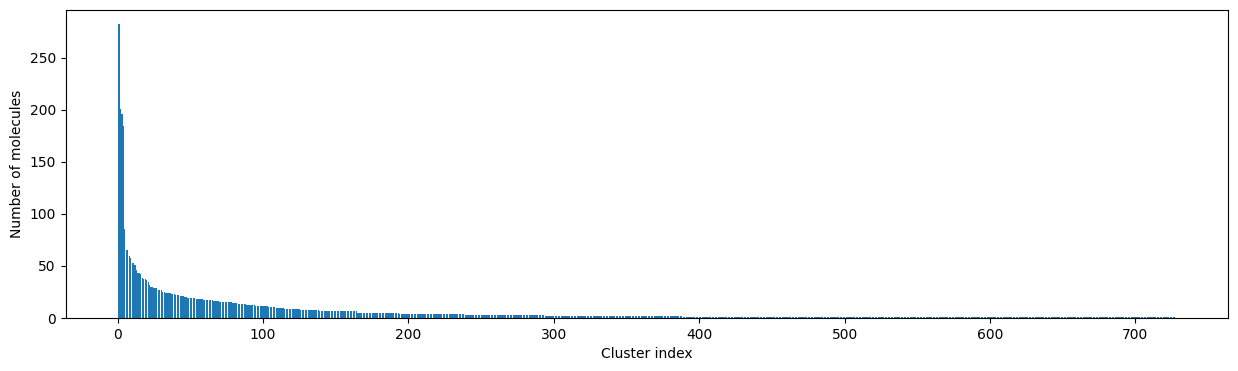

In [12]:
# Plot the size of the clusters
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlabel("Cluster index")
ax.set_ylabel("Number of molecules")
ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5);

#### 如何选择合理的阈值？

由于聚类结果取决于用户选择的阈值，我们将对一系列距离阈值进行聚类评估。

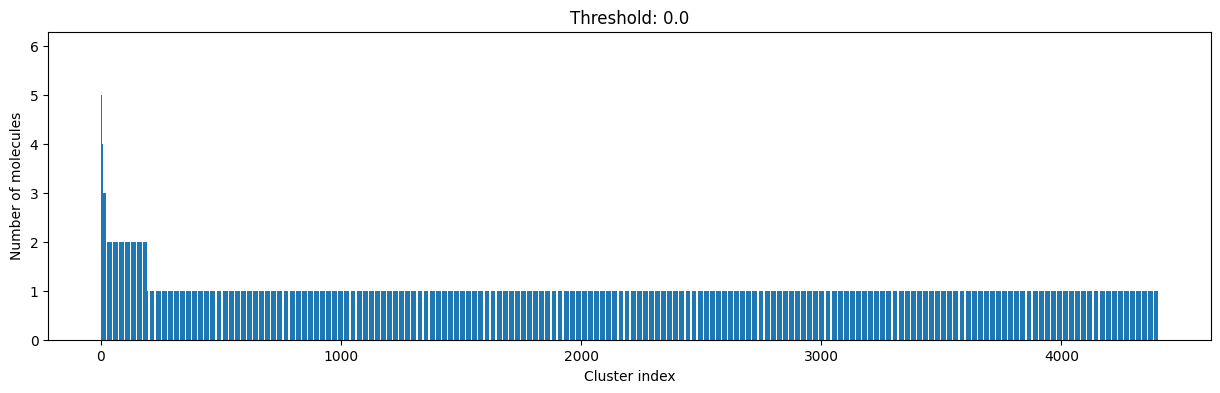

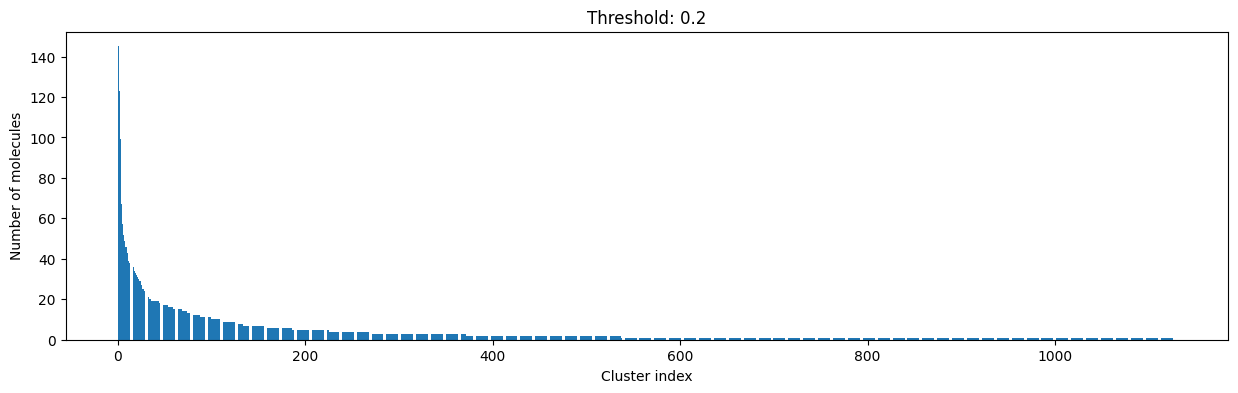

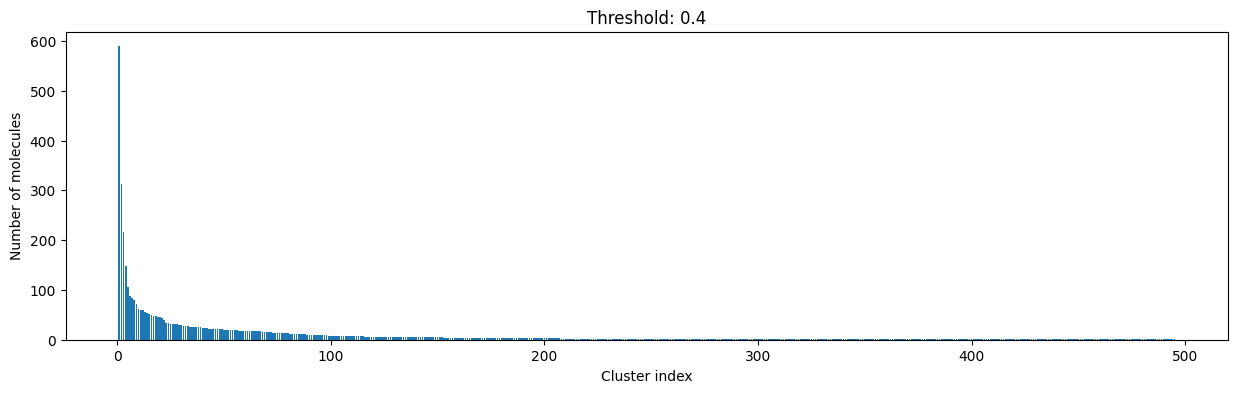

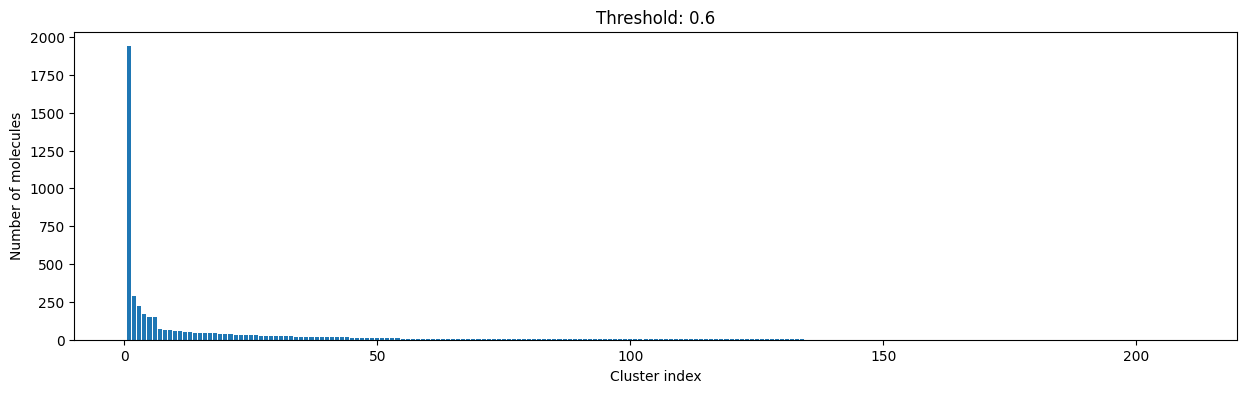

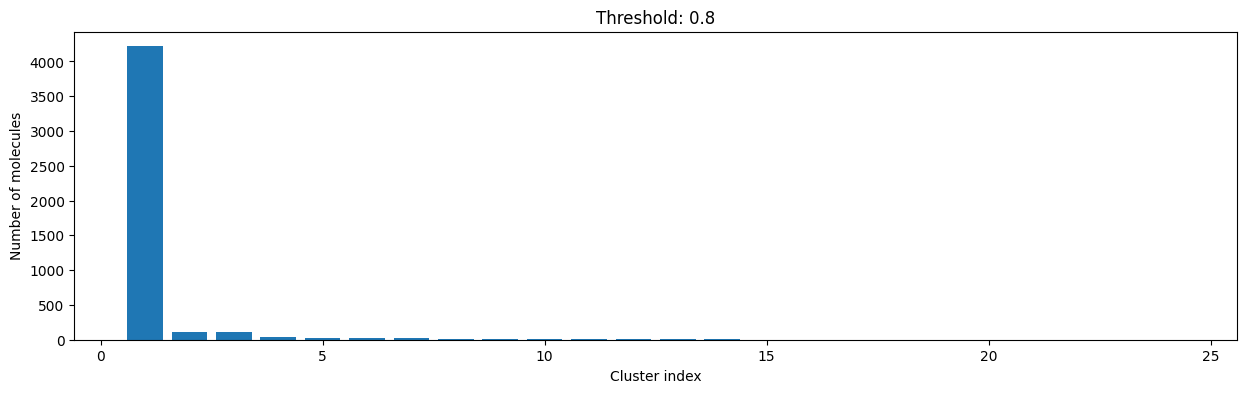

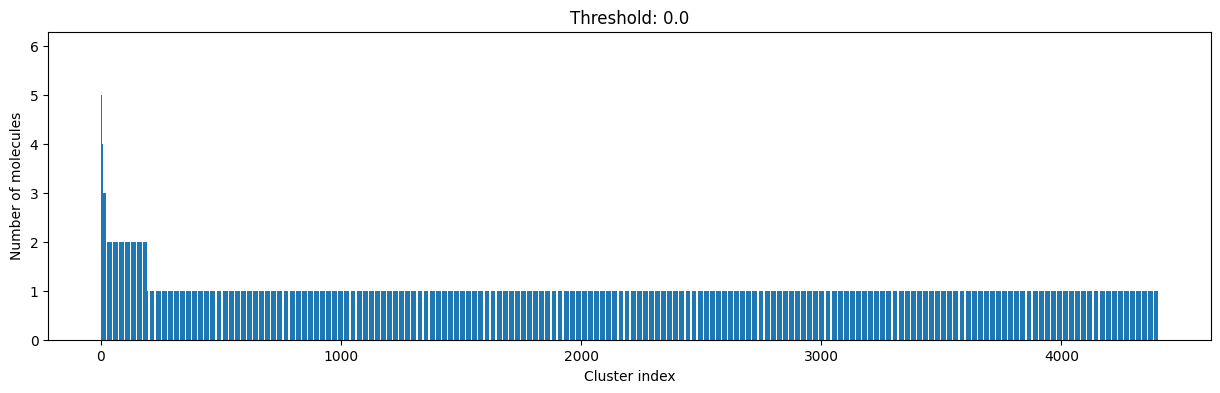

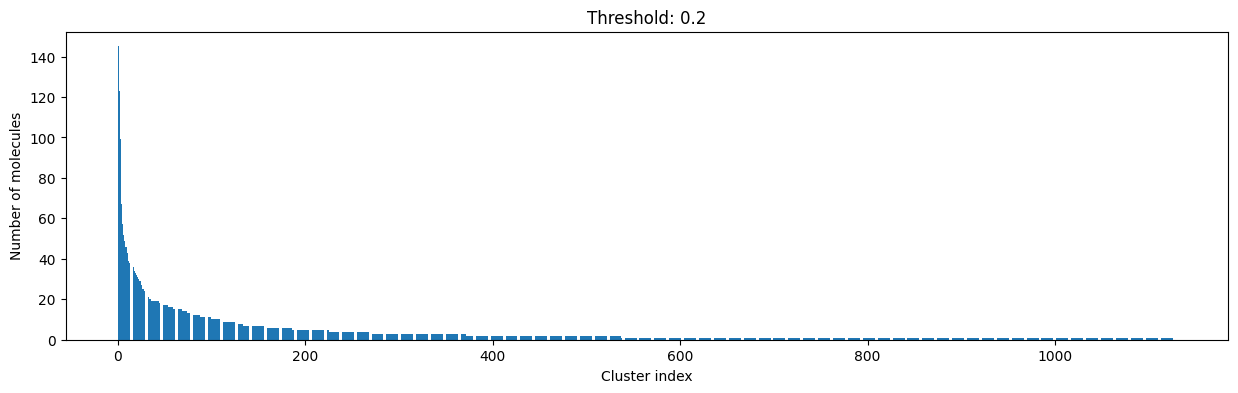

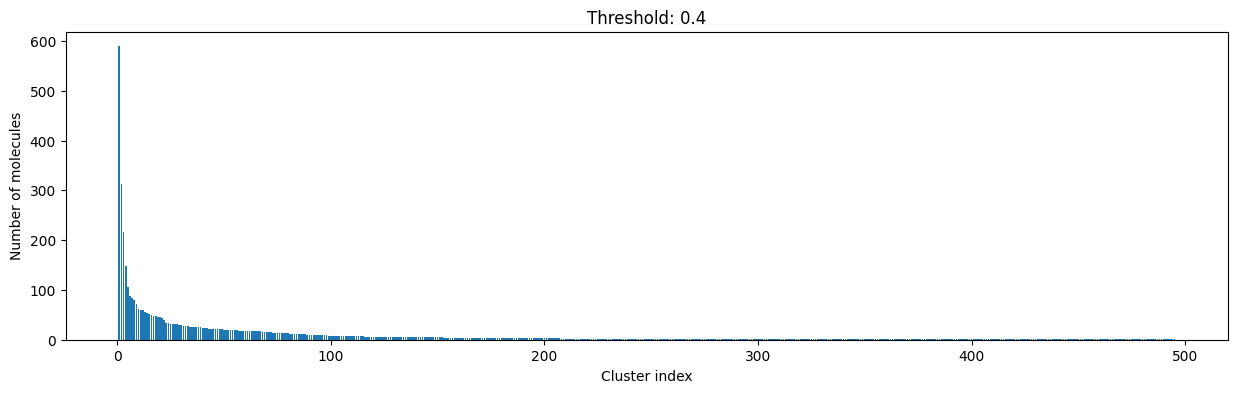

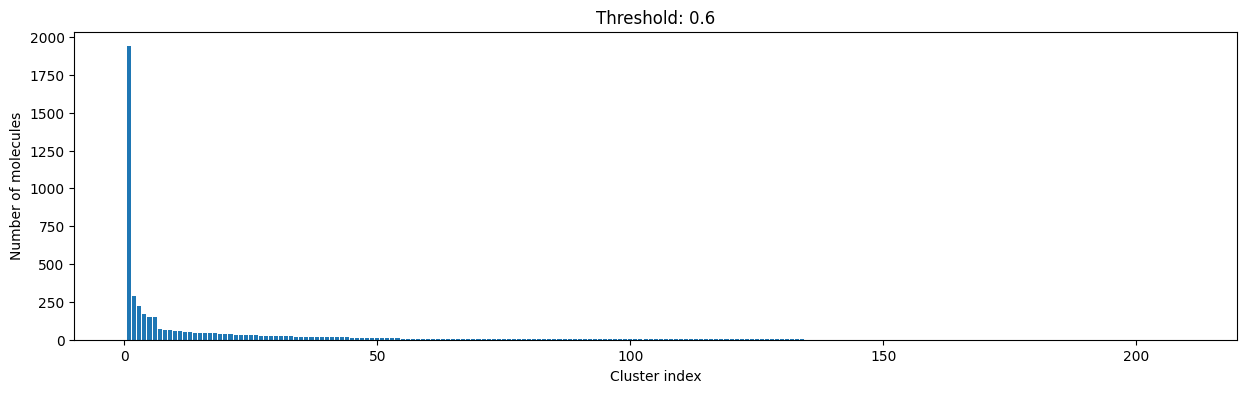

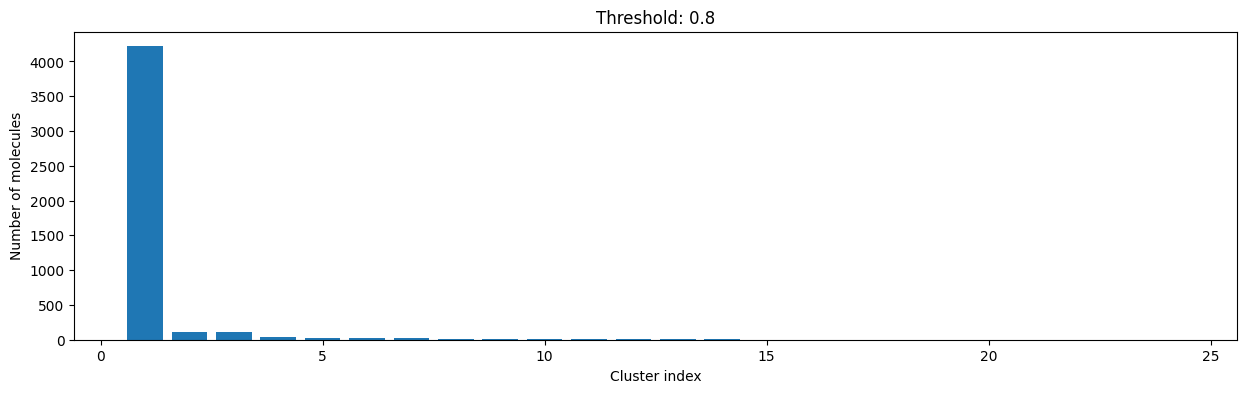

In [13]:
for cutoff in np.arange(0.0, 1.0, 0.2):
    clusters = cluster_fingerprints(fingerprints, cutoff=cutoff)
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.set_title(f"Threshold: {cutoff:3.1f}")
    ax.set_xlabel("Cluster index")
    ax.set_ylabel("Number of molecules")
    ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters], lw=5)
    display(fig)

正如您所看到的，阈值（距离截断值）越高，被认定为相似的分子就越多，因此聚类的数量越少，但每个簇中的分子数量越多（但相似性较低）。

阈值的合理选择取决于数据中预期的相似性以及预期簇的数量和大小。

Number of clusters: 1128 from 4635 molecules at distance cut-off 0.20
Number of molecules in largest cluster: 145
Similarity between two random points in same cluster: 0.82
Similarity between two random points in different cluster: 0.22


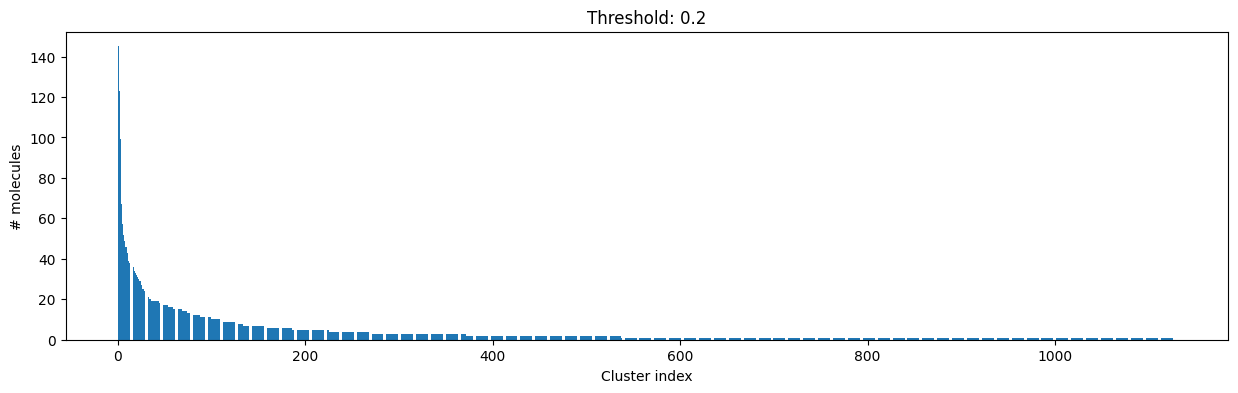

In [14]:
cutoff = 0.2
clusters = cluster_fingerprints(fingerprints, cutoff=cutoff)

# Plot the size of the clusters - save plot
fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlabel("Cluster index")
ax.set_ylabel("# molecules")
ax.bar(range(1, len(clusters) + 1), [len(c) for c in clusters])
ax.set_title(f"Threshold: {cutoff:3.1f}")
fig.savefig(
    DATA / f"cluster_dist_cutoff_{cutoff:4.2f}.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

print(
    f"Number of clusters: {len(clusters)} from {len(compounds)} molecules at distance cut-off {cutoff:.2f}"
)
print("Number of molecules in largest cluster:", len(clusters[0]))
print(
    f"Similarity between two random points in same cluster: {DataStructs.TanimotoSimilarity(fingerprints[clusters[0][0]], fingerprints[clusters[0][1]]):.2f}"
)
print(
    f"Similarity between two random points in different cluster: {DataStructs.TanimotoSimilarity(fingerprints[clusters[0][0]], fingerprints[clusters[1][0]]):.2f}"
)

### Visualizing the clusters

#### 最大簇中的十个示例

现在，让我们仔细看看最大簇中的前十个簇成员。

Ten molecules from largest cluster:


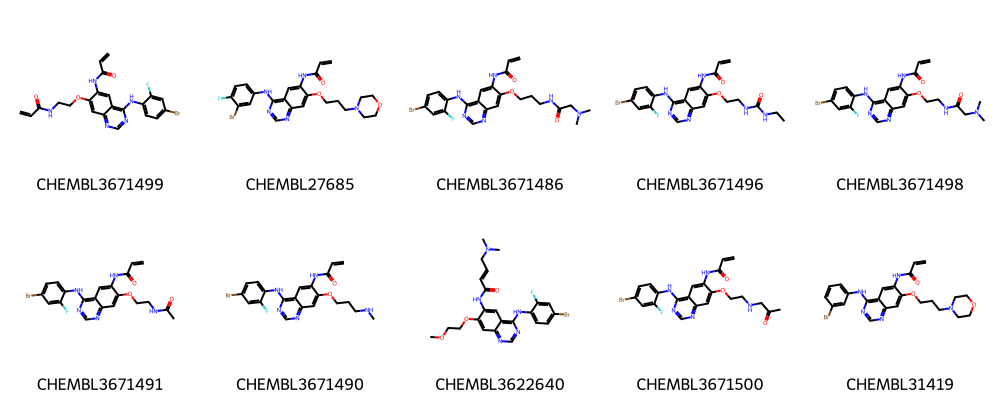

In [15]:
print("Ten molecules from largest cluster:")
# Draw molecules
Draw.MolsToGridImage(
    [compounds[i][0] for i in clusters[0][:10]],
    legends=[compounds[i][1] for i in clusters[0][:10]],
    molsPerRow=5,
)

In [16]:
# Save molecules from largest cluster so other talktorials can use it
sdf_path = str(DATA / "molecule_set_largest_cluster.sdf")
sdf = Chem.SDWriter(sdf_path)
for index in clusters[0]:
    mol, label = compounds[index]
    # Add label to metadata
    mol.SetProp("_Name", label)
    sdf.write(mol)
sdf.close()

#### 10 examples from second largest cluster

Ten molecules from second largest cluster:


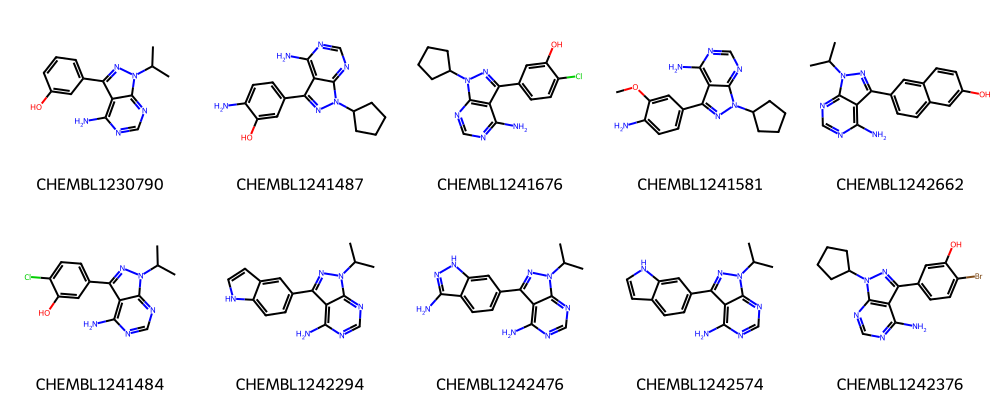

In [17]:
print("Ten molecules from second largest cluster:")
# Draw molecules
Draw.MolsToGridImage(
    [compounds[i][0] for i in clusters[1][:10]],
    legends=[compounds[i][1] for i in clusters[1][:10]],
    molsPerRow=5,
)

各个簇中的前十分子看起来确实彼此相似，并且有趣的是，与不同簇中的分子不同。

#### 前 10 个簇的示例

为了比较，我们查看前 10 个簇的簇中心。

Ten molecules from first 10 clusters:


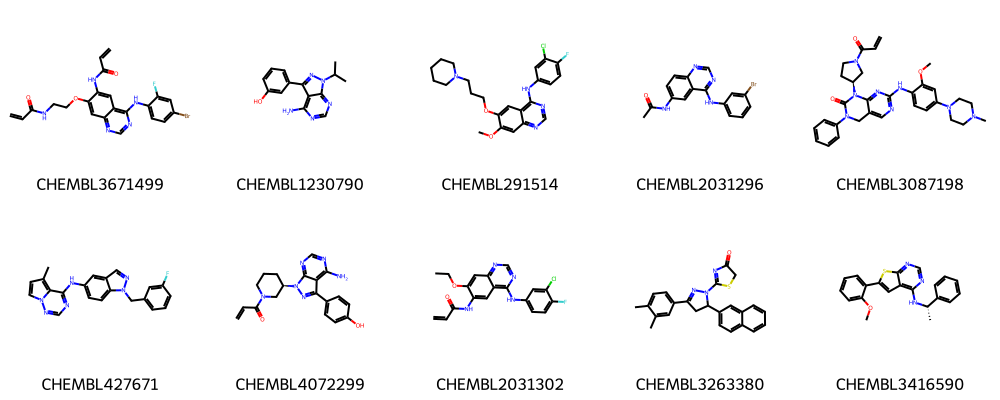

In [18]:
print("Ten molecules from first 10 clusters:")
# Draw molecules
Draw.MolsToGridImage(
    [compounds[clusters[i][0]][0] for i in range(10)],
    legends=[compounds[clusters[i][0]][1] for i in range(10)],
    molsPerRow=5,
)

Save cluster centers from first 3 clusters as SVG file.

In [19]:
# Generate image
img = Draw.MolsToGridImage(
    [compounds[clusters[i][0]][0] for i in range(0, 3)],
    legends=[f"Cluster {i}" for i in range(1, 4)],
    subImgSize=(200, 200),
    useSVG=True,
)

# Patch RAW svg data: convert non-transparent to transparent background and set font size
molsvg = img.data.replace("opacity:1.0", "opacity:0.0").replace("12px", "20px")

# Save altered SVG data to file
with open(DATA / "cluster_representatives.svg", "w") as f:
    f.write(molsvg)

虽然仍然可以看到一些相似性，但很明显，不同簇的质心看起来比我们之前看到的簇中分子之间的差异更大。

#### 簇内 Tanimoto 相似性

我们还可以查看簇内的 Tanimoto 相似性，即第一个簇成员与所有其他簇成员之间的 Tanimoto 相似性。

In [20]:
def intra_tanimoto(fps_clusters):
    """Function to compute Tanimoto similarity for all pairs of fingerprints in each cluster"""
    intra_similarity = []
    # Calculate intra similarity per cluster
    for cluster in fps_clusters:
        # Tanimoto distance matrix function converted to similarity matrix (1-distance)
        intra_similarity.append([1 - x for x in tanimoto_distance_matrix(cluster)])
    return intra_similarity

In [21]:
# Recompute fingerprints for 10 first clusters
mol_fps_per_cluster = []
for cluster in clusters[:10]:
    mol_fps_per_cluster.append([rdkit_gen.GetFingerprint(compounds[i][0]) for i in cluster])

# Compute intra-cluster similarity
intra_sim = intra_tanimoto(mol_fps_per_cluster)

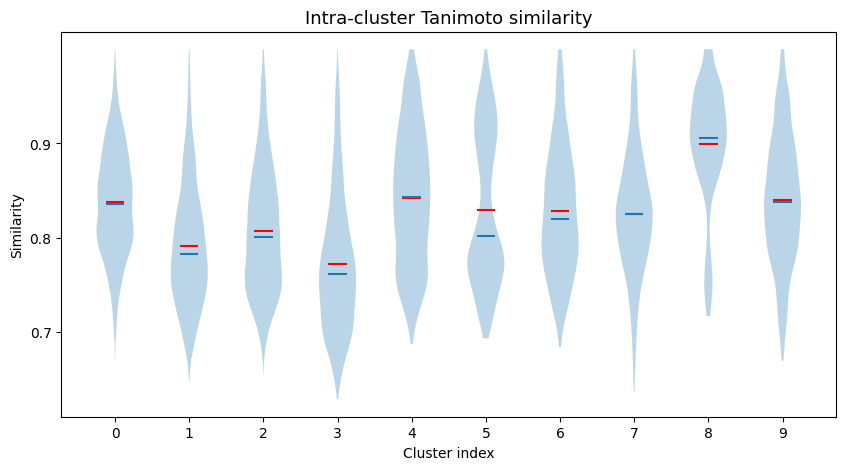

In [22]:
# Violin plot with intra-cluster similarity

fig, ax = plt.subplots(figsize=(10, 5))
indices = list(range(10))
ax.set_xlabel("Cluster index")
ax.set_ylabel("Similarity")
ax.set_xticks(indices)
ax.set_xticklabels(indices)
ax.set_yticks(np.arange(0.6, 1.0, 0.1))
ax.set_title("Intra-cluster Tanimoto similarity", fontsize=13)
r = ax.violinplot(intra_sim, indices, showmeans=True, showmedians=True, showextrema=False)
r["cmeans"].set_color("red")
# mean=red, median=blue

### 选择最终化合物列表

接下来，我们要从我们的聚类中选择化合物列表。我们选择每个簇的__质心__来收集（尽可能）多样化的化合物列表。

Get cluster centers.

In [23]:
# Get the cluster center of each cluster (first molecule in each cluster)
cluster_centers = [compounds[c[0]] for c in clusters]
# How many cluster centers/clusters do we have?
print("Number of cluster centers:", len(cluster_centers))
# NBVAL_CHECK_OUTPUT

Number of cluster centers: 1128


按大小排序簇，并按相似性排序每个簇中的分子。

In [24]:
# Sort the molecules within a cluster based on their similarity
# to the cluster center and sort the clusters based on their size
sorted_clusters = []
for cluster in clusters:
    if len(cluster) <= 1:
        continue  # Singletons
    # else:
    # Compute fingerprints for each cluster element
    sorted_fingerprints = [rdkit_gen.GetFingerprint(compounds[i][0]) for i in cluster]
    # Similarity of all cluster members to the cluster center
    similarities = DataStructs.BulkTanimotoSimilarity(
        sorted_fingerprints[0], sorted_fingerprints[1:]
    )
    # Add index of the molecule to its similarity (centroid excluded!)
    similarities = list(zip(similarities, cluster[1:]))
    # Sort in descending order by similarity
    similarities.sort(reverse=True)
    # Save cluster size and index of molecules in clusters_sort
    sorted_clusters.append((len(similarities), [i for _, i in similarities]))
    # Sort in descending order by cluster size
    sorted_clusters.sort(reverse=True)

Pick a maximum of 1000 compounds.

In [25]:
# Count selected molecules, pick cluster centers first
selected_molecules = cluster_centers.copy()
# Take 10 molecules (or a maximum of 50%) of each cluster starting with the largest one
index = 0
pending = 1000 - len(selected_molecules)
while pending > 0 and index < len(sorted_clusters):
    # Take indices of sorted clusters
    tmp_cluster = sorted_clusters[index][1]
    # If the first cluster is > 10 big then take exactly 10 compounds
    if sorted_clusters[index][0] > 10:
        num_compounds = 10
    # If smaller, take half of the molecules
    else:
        num_compounds = int(0.5 * len(tmp_cluster)) + 1
    if num_compounds > pending:
        num_compounds = pending
    # Write picked molecules and their structures into list of lists called picked_fps
    selected_molecules += [compounds[i] for i in tmp_cluster[:num_compounds]]
    index += 1
    pending = 1000 - len(selected_molecules)
print("# Selected molecules:", len(selected_molecules))
# NBVAL_CHECK_OUTPUT

# Selected molecules: 1128


这组多样化的分子现在可以用于实验测试。

### 奖励：运行时间分析

在本教程的最后，我们可以与以下参数玩耍，来探索聚类算法的运行时间如何随我们为聚类定义的阈值而变化。

In [26]:
# Reuse old dataset
sampled_mols = compounds.copy()

注意，您可以尝试更大的数据集，但超过 10000 个数据点的数据集已经开始消耗相当多的时间，并可能导致 Jupyter 内核崩溃（取决于您的机器）。

In [27]:
# Helper function for time computation
def measure_runtime(sampled_mols):
    start_time = time.time()
    sampled_fingerprints = [rdkit_gen.GetFingerprint(m) for m, idx in sampled_mols]
    # Run the clustering with the dataset
    sampled_clusters = cluster_fingerprints(sampled_fingerprints, cutoff=0.3)
    return time.time() - start_time

In [28]:
len(sampled_mols)
# NBVAL_CHECK_OUTPUT

4635

In [29]:
sample_sizes = [100, 500, 1000, 2000, 4000]
runtimes = []
# Take random samples with replacement
for size in sample_sizes:
    time_taken = measure_runtime(random.sample(sampled_mols, size))
    print(f"Dataset size {size}, time {time_taken:4.2f} seconds")
    runtimes.append(time_taken)

Dataset size 100, time 0.04 seconds
Dataset size 500, time 0.23 seconds
Dataset size 1000, time 0.53 seconds
Dataset size 2000, time 1.30 seconds
Dataset size 4000, time 3.48 seconds


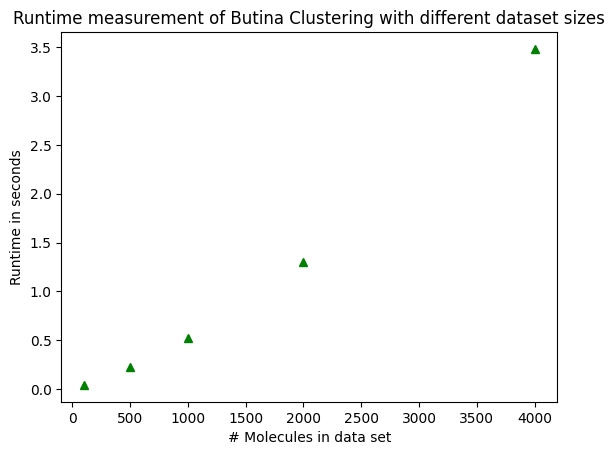

In [30]:
fig, ax = plt.subplots()
ax.set_title("Runtime measurement of Butina Clustering with different dataset sizes")
ax.set_xlabel("# Molecules in data set")
ax.set_ylabel("Runtime in seconds")
ax.plot(sample_sizes, runtimes, "g^");

请注意运行时间并不完全与样本大小成正比！它增长得更快！

## 讨论

我们介绍了 Butina 算法来对化学化合物数据集进行聚类，以获得多样化的化合物集合。同样，可以使用更多样化的化学信息学方法，基于不同的化合物特征来识别代表性化合物。我们的化合物数据集现在已准备好进行机器学习分析（参见**教程 T007**）。

## 课后思考

* 为什么分子聚类很重要？
* 您可以使用哪些算法对分子集进行聚类，它们的优缺点是什么？
* 我们的数据集为下一步分析（**教程 T007**）准备好了吗？